## Computer Vision - Part 1

### Coordinates and Transformation Matrices in Robotics

Coordinates are frameworks used to define the position and orientation of objects in space. In robotics, we often use different coordinate systems to represent the robot's position, the position of objects in the environment, and the position of the robot's end-effector (the part of the robot that interacts with objects).

#### Types of Coordinate Systems
1. **World Coordinate System**: A fixed coordinate system that serves as a reference for all other coordinate systems. It is typically defined at the base of the robot or at a specific point in the environment.
2. **Robot Coordinate System**: A coordinate system that is attached to the robot itself. It moves with the robot and is often used to describe the position of the robot's joints and end-effector.
3. **End-Effector Coordinate System**: A coordinate system attached to the robot's end-effector. It is used to describe the position and orientation of the end-effector relative to the robot or the world.

For example:
- 2D coordinates can be represented as (x, y) in a plane.
- 3D coordinates can be represented as (x, y, z) in space.

**Transformation Matrices**: To convert between different coordinate systems, we use transformation matrices. A transformation matrix is a mathematical tool that allows us to perform operations such as translation, rotation, and scaling on coordinates. In robotics, we often use homogeneous transformation matrices, which are 4x4 matrices that can represent both rotation and translation in 3D space.

In [76]:
!pip install spatialmath-python
# !pip install rvc3python 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


**The SpatialMath Library**: The SpatialMath library provides tools for working with transformation matrices in robotics. It allows us to easily create and manipulate transformation matrices, making it easier to perform coordinate transformations and understand the relationships between different coordinate systems.

**The RVC3Python Library**: The RVC3Python library is a Python implementation of the Robotics, Vision, and Control (RVC) textbook. It provides tools for working with robotics concepts, including transformation matrices, kinematics, and control. It is a valuable resource for learning and applying robotics principles in Python.

In [77]:
from spatialmath import SO2, SO3, SE2, SE3

#### 2D Rotation Matrix

2D rotation can be represented by a 2x2 matrix. The rotation matrix for an angle θ is given by:

$$R(θ) = \begin{bmatrix} \cos(θ) & -\sin(θ) \\ \sin(θ) & \cos(θ) \end{bmatrix}$$

This matrix can be used to rotate a point (x, y) by multiplying it with the rotation matrix:

$$[x', y'] = R(θ) * [x, y]$$

This is a 2×2 matrix that belongs to the group SO(2) — the Special Orthogonal group in 2 dimensions.

Think of it as a way to rotate a point in a 2D plane by an angle θ. The new coordinates (x', y') are obtained by applying the rotation to the original coordinates (x, y).

Here we choose an angle of 45 degrees to create a rotation matrix. The matrix has the form of:

$$R(45°) = \begin{bmatrix} \cos(45°) & -\sin(45°) \\ \sin(45°) & \cos(45°) \end{bmatrix}$$


In [78]:
# Create a rotation of 45 degrees
R = SO2(45, unit='deg')
print(R)
# Access the underlying numpy array
# A here stands for the actual matrix representation of the rotation
print(R.A)
print("Shape of R.A:", R.A.shape)
# Verify orthogonality: R * R.T should be identity
print(R * R.inv())

   0.7071   -0.7071    
   0.7071    0.7071    

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Shape of R.A: (2, 2)
   1         0         
   0         1         



If we change the angle to 60 degrees, we can see how the rotation matrix changes:

$$R(60°) = \begin{bmatrix} \cos(60°) & -\sin(60°) \\ \sin(60°) & \cos(60°) \end{bmatrix}$$

In [79]:
R = SO2(60, unit='deg')
print(R)

   0.5      -0.866     
   0.866     0.5       



#### 3D Rotation Matrix

3D rotation can be represented by a 3x3 matrix. 

The rotation matrix for an angle θ around the x-axis (ROLL) is given by:

$$R_x(θ) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos(θ) & -\sin(θ) \\ 0 & \sin(θ) & \cos(θ) \end{bmatrix}$$

The rotation matrix for an angle θ around the y-axis (PITCH) is given by:

$$R_y(θ) = \begin{bmatrix} \cos(θ) & 0 & \sin(θ) \\ 0 & 1 & 0 \\ -\sin(θ) & 0 & \cos(θ) \end{bmatrix}$$

The rotation matrix for an angle θ around the z-axis (YAW) is given by:

$$R_z(θ) = \begin{bmatrix} \cos(θ) & -\sin(θ) & 0 \\ \sin(θ) & \cos(θ) & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

This matrix can be used to rotate a point (x, y, z) by multiplying it with the rotation matrix:

$$[x', y', z'] = R(θ) * [x, y, z]$$

This is a 3×3 matrix that belongs to the group SO(3) — the Special Orthogonal group in 3 dimensions.

For Rx(30°), we have:
$$R_x(30°) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos(30°) & -\sin(30°) \\ 0 & \sin(30°) & \cos(30°) \end{bmatrix}$$

For Ry(45°), we have:
$$R_y(45°) = \begin{bmatrix} \cos(45°) & 0 & \sin(45°) \\ 0 & 1 & 0 \\ -\sin(45°) & 0 & \cos(45°) \end{bmatrix}$$

For Rz(60°), we have:
$$R_z(60°) = \begin{bmatrix} \cos(60°) & -\sin(60°) & 0 \\ \sin(60°) & \cos(60°) & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

In [80]:
# Individual axis rotations
Rx = SO3.Rx(30, unit='deg')
Ry = SO3.Ry(45, unit='deg')
Rz = SO3.Rz(60, unit='deg')
print("Rx:\n", Rx)
print("Ry:\n", Ry)
print("Rz:\n", Rz)
# Compose: first rotate around X, then Y
R = Rx * Ry
print("R = Rx * Ry:\n", R)
print("det(R) =", R.det()) # Should be 1.0
print("R*R.T =", (R * R.inv()).A) # Should be Identity

Rx:
    1         0         0         
   0         0.866    -0.5       
   0         0.5       0.866     

Ry:
    0.7071    0         0.7071    
   0         1         0         
  -0.7071    0         0.7071    

Rz:
    0.5      -0.866     0         
   0.866     0.5       0         
   0         0         1         

R = Rx * Ry:
    0.7071    0         0.7071    
   0.3536    0.866    -0.3536    
  -0.6124    0.5       0.6124    

det(R) = 1.0
R*R.T = [[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 5.55111512e-17]
 [0.00000000e+00 5.55111512e-17 1.00000000e+00]]


#### Homogeneous Transformation Matrices
In robotics, we often need to represent both rotation and translation in a single matrix. This is where homogeneous transformation matrices come into play. A homogeneous transformation matrix is a 4x4 matrix that can represent both rotation and translation in 3D space.
- Rotation: 3×3 matrix R
- Translation: 3×1 vector p
Combined, they form a homogeneous transformation matrix T:
$$T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} R_{11} & R_{12} & R_{13} & p_1 \\ R_{21} & R_{22} & R_{23} & p_2 \\ R_{31} & R_{32} & R_{33} & p_3 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

Where:
- R is the 3×3 rotation matrix.
- p is the 3×1 translation vector.
- The last row [0, 0, 0, 1] is used to maintain the homogeneous property of the transformation matrix.

#### SE(2) Transformation

SE(2) is the group of rigid body transformations in 2D space. It combines both rotation and translation. A transformation in SE(2) can be represented as a 3x3 homogeneous transformation matrix:
$$T = \begin{bmatrix} R & t \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} \cos(θ) & -\sin(θ) & t_x \\ \sin(θ) & \cos(θ) & t_y \\ 0 & 0 & 1 \end{bmatrix}$$

Where:
- R is the 2×2 rotation matrix.
- t is the 2×1 translation vector (t_x, t_y).

The plot below shows a point (x, y) being rotated by an angle θ and then translated by (t_x, t_y) in the 2D plane. The original point is shown in blue, the rotated point in green, and the final transformed point in red.

   0.7071   -0.7071    2         
   0.7071    0.7071    3         
   0         0         1         

Translation: [2. 3.]
Rotation: 0.7853981633974482


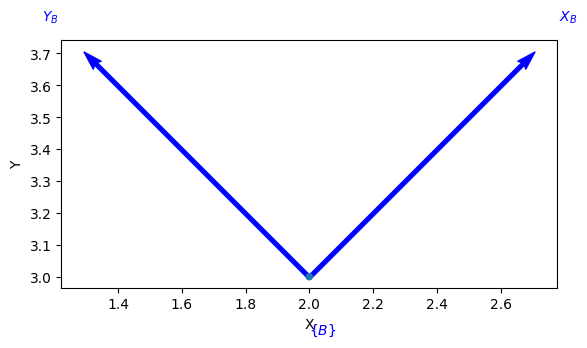

In [81]:
# Translate by (2, 3) and rotate by 45 degrees
T = SE2(2, 3, 45, unit='deg')
print(T)
print("Translation:", T.t) # [2, 3]
print("Rotation:", T.theta()) # 45 degrees
# Visualize (if matplotlib available)
T.plot(frame='B', color='blue')

#### SE[3] Pose

SE(3) is the group of rigid body transformations in 3D space. It combines both rotation and translation. A transformation in SE(3) can be represented as a 4x4 homogeneous transformation matrix:
$$T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} R_{11} & R_{12} & R_{13} & p_1 \\ R_{21} & R_{22} & R_{23} & p_2 \\ R_{31} & R_{32} & R_{33} & p_3 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$
Where:
- R is the 3×3 rotation matrix.
- p is the 3×1 translation vector. 

In [82]:
# Translate to (1, 2, 3), then rotate 90° around Z
T = SE3(1, 2, 3) * SE3.Rz(90, unit='deg')
print(T)
print("Position:", T.t) # [1, 2, 3]
print("Rotation matrix:\n", T.R)
# Decompose the rotation to Euler angles
print("RPY angles:", T.rpy(unit='deg'))

   0        -1         0         1         
   1         0         0         2         
   0         0         1         3         
   0         0         0         1         

Position: [1. 2. 3.]
Rotation matrix:
 [[ 6.123234e-17 -1.000000e+00  0.000000e+00]
 [ 1.000000e+00  6.123234e-17  0.000000e+00]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]
RPY angles: [ 0. -0. 90.]


#### Transforming a Point

Tranforming a point from one coordinate system to another can be done using the transformation matrix. If we have a point represented in homogeneous coordinates as (x, y, z, 1), we can apply the transformation T to get the new coordinates (x', y', z', 1):

$$[x', y', z', 1] = T * [x, y, z, 1]$$

This allows us to easily convert points between different coordinate systems, which is essential in robotics for tasks such as motion planning, control, and perception.

Original: [1, 0, 0]
Transformed: [[1.]
 [1.]
 [0.]]


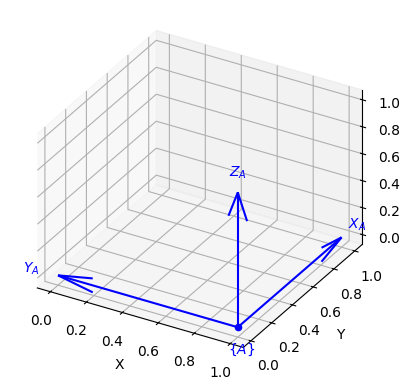

In [83]:
# Define transformation: move 1 unit along X, rotate 90° around Z
T = SE3(1, 0, 0) * SE3.Rz(90, unit='deg')
# Original point in local frame
point = [1, 0, 0]
# Transform point to world frame
new_point = T * point
print("Original:", point)
print("Transformed:", new_point) # [1, 1, 0]
T.plot(frame='A', color='blue')

#### Inverse Transformation

Inverse transformation is the process of finding the transformation that undoes the effect of a given transformation. If we have a transformation T, its inverse T^-1 can be computed as follows:
$$T^{-1} = \begin{bmatrix} R^T & -R^T p \\ 0 & 1 \end{bmatrix}$$
Where R^T is the transpose of the rotation matrix R, and -R^T p is the negative of the product of the transpose of R and the translation vector p. This inverse transformation can be used to convert points back to their original coordinate system or to undo a transformation applied to an object.

T * T_inv:
    1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         

T_inv translation: [-2.         -4.94974747 -0.70710678]
T_inv rotation:
 [[ 1.          0.          0.        ]
 [ 0.          0.70710678  0.70710678]
 [ 0.         -0.70710678  0.70710678]]


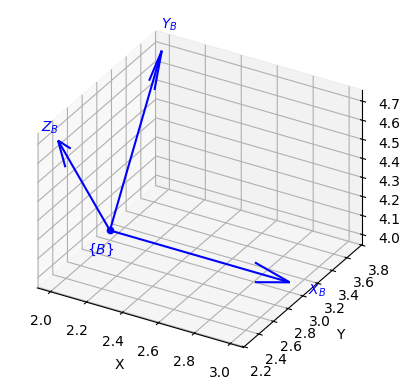

In [84]:
# Create a complex transformation
T = SE3(2, 3, 4) * SE3.Rx(45, unit='deg')
# Compute the inverse
T_inv = T.inv()
# Verify: T * T_inv should equal Identity
result = T * T_inv
print("T * T_inv:\n", result) # Should be Identity 4x4
# Direct computation
print("T_inv translation:", T_inv.t)
print("T_inv rotation:\n", T_inv.R)
T.plot(frame='B', color='blue')

#### Euler Angles (RPY)

Euler angles, also known as Roll-Pitch-Yaw (RPY), are a way to represent the orientation of an object in 3D space using three angles. The roll angle (φ) represents rotation around the x-axis, the pitch angle (θ) represents rotation around the y-axis, and the yaw angle (ψ) represents rotation around the z-axis. These angles can be used to construct a rotation matrix that describes the orientation of an object in space. However, Euler angles can suffer from gimbal lock, which is a loss of one degree of freedom in certain configurations.

Rotation matrix:
    0.3536   -0.5732    0.7392    
   0.6124    0.7392    0.2803    
  -0.7071    0.3536    0.6124    

Extracted RPY: [30. 45. 60.]
Round-trip error: [-3.55271368e-15 -7.10542736e-15 -7.10542736e-15]


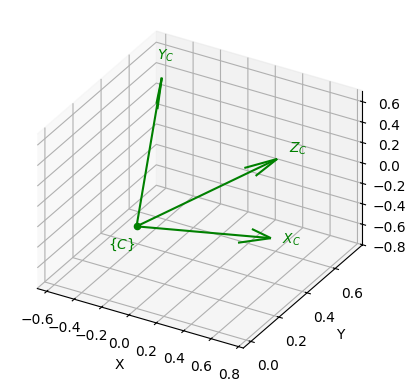

In [85]:
# Create rotation from RPY angles
R = SO3.RPY([30, 45, 60], unit='deg')
print("Rotation matrix:\n", R)
# Extract RPY angles back from matrix
angles = R.rpy(unit='deg')
print("Extracted RPY:", angles) # Should be [30, 45, 60]
# Verify round-trip consistency
print("Round-trip error:",
angles - [30, 45, 60])
# Plot R
R.plot(frame='C', color='green')

In [86]:
from spatialmath import UnitQuaternion
from spatialmath import SE3
from spatialmath.base import trplot
import matplotlib.pyplot as plt

#### Quaternions

Quaternions are a mathematical representation of orientation in 3D space that avoids the problem of gimbal lock associated with Euler angles. A quaternion is represented as a four-dimensional vector (q_w, q_x, q_y, q_z) where q_w is the scalar part and (q_x, q_y, q_z) is the vector part. Quaternions can be used to represent rotations and can be converted to and from rotation matrices. They are often used in robotics and computer graphics for smooth interpolation of orientations and efficient computation of rotations.

Quaternion:  0.7071 <<  0.0000,  0.0000,  0.7071 >>
w: 0.7071067811865476  xyz: [0.         0.         0.70710678]
Rotation matrix:
 [[ 2.22044605e-16 -1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  2.22044605e-16  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Combined:  0.6533 <<  0.2706,  0.2706,  0.6533 >>
Combined RPY angles: [45. -0. 90.]


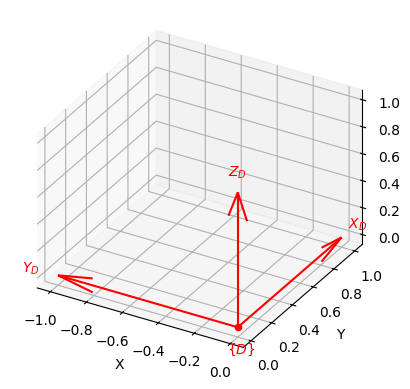

In [87]:
# Create quaternion for 90° rotation around Z
q = UnitQuaternion.Rz(90, unit='deg')
print("Quaternion:", q)
print("w:", q.s, " xyz:", q.v)
# Convert to rotation matrix
R = q.SO3()
R = q.R 
print("Rotation matrix:\n", R)
# Quaternion multiplication (composition)
q2 = UnitQuaternion.Rx(45, unit='deg')
q_combined = q * q2
print("Combined:", q_combined)
# Convert back to RPY angles
angles = q_combined.rpy(unit='deg')
print("Combined RPY angles:", angles)
# Plot
trplot(R, frame='D', color='red')
plt.show()

#### Visualizing Transformations

Visualizing transformations can help us understand how different coordinate systems relate to each other and how points are transformed. We can use libraries such as Matplotlib in Python to plot the original and transformed points, as well as the coordinate frames. This visual representation can be particularly helpful when working with complex transformations in 3D space.

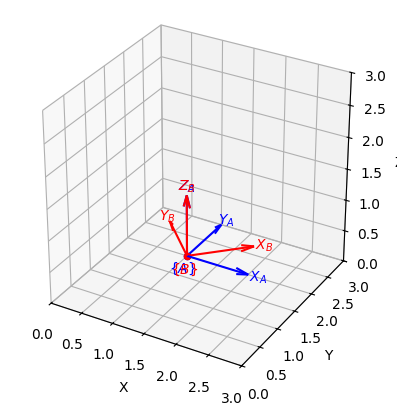

In [88]:
# Create two frames
T1 = SE3(1, 2, 0)
T2 = T1 * SE3.Rz(45, unit='deg')
# Plot both frames
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
trplot(T1.A, frame='A', color='blue', dims=[0, 3, 0, 3, 0, 3], ax=ax)
trplot(T2.A, frame='B', color='red', ax=ax)
plt.show()

## Mini Project: Robot in 3D Space

Bring all the concepts together in a complete mini-project:

- Create the Robot Base Frame

Define `T_base = SE3(0, 0, 0)` as the world origin of the robot. This is the starting point of all calculations.

To convert degrees to the theta (θ) value used in most robotics libraries (which require radians), use this formula:

$$θ (radians) = θ (degrees) × (π / 180)$$

In [89]:
import numpy as np

def rotate_point(axis, point, angle_deg):
    theta = 60 * (np.pi / 180)
    if axis == 'z':
        R = SO3.Rz(angle_deg, unit='deg').R
    elif axis == 'y':
        R = SO3.Ry(angle_deg, unit='deg').R
    elif axis == 'x':
        R = SO3.Rx(angle_deg, unit='deg').R
    else:
        raise ValueError("Invalid axis. Please choose 'x', 'y', or 'z'.")

    # Rotate point (applying the rotation matrix)
    rotated_point = R @ point
    return rotated_point

In [90]:
import numpy as np

T_base = SE3(0, 0, 0)
print("Base Matrix:\n", T_base)

# Simulate robot rotation (35 degree to X-Axis)
theta = 35 * (np.pi / 180)
rotation = SE3.Rx(theta)
# Calculate new pose
NewPose = T_base * rotation
# This will return the Rz matrix
print("\nRotated Pose (35 degree to X-Axis):\n", NewPose)

# 60 degree to Y Axis
theta = 60 * (np.pi / 180)
rotation = SE3.Ry(theta)
# Calculate new pose
NewPose = T_base * rotation
# This will return the Rz matrix
print("\nRotated Pose (60 degree to Y-Axis):\n", NewPose)


# Simulate robot rotation (45 degree to Z-Axis)
theta = 45 * (np.pi / 180)
rotation = SE3.Rz(theta)
# Calculate new pose
NewPose = T_base * rotation
# This will return the Rz matrix
print("\nRotated Pose (45 degree to Z-Axis):\n", NewPose)

Base Matrix:
    1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         


Rotated Pose (35 degree to X-Axis):
    1         0         0         0         
   0         0.8192   -0.5736    0         
   0         0.5736    0.8192    0         
   0         0         0         1         


Rotated Pose (60 degree to Y-Axis):
    0.5       0         0.866     0         
   0         1         0         0         
  -0.866     0         0.5       0         
   0         0         0         1         


Rotated Pose (45 degree to Z-Axis):
    0.7071   -0.7071    0         0         
   0.7071    0.7071    0         0         
   0         0         1         0         
   0         0         0         1         



- Define an Object Frame
Place an object at an arbitrary position and orientation, e.g., `T_obj = SE3(3, 2, 1) *
SE3.Rz(30, unit='deg')`

In [91]:
T_obj = SE3(3, 2, 1) * SE3.Rz(30, unit='deg')
print("Object Frame (Initial):\n", T_obj)

Object Frame (Initial):
    0.866    -0.5       0         3         
   0.5       0.866     0         2         
   0         0         1         1         
   0         0         0         1         



In [92]:
T_reach = T_base.inv() * T_obj

In [93]:
print("Robot Base\n", T_base)
print("\nObject Pose\n", T_obj)
print("\nRelative Reach (Instructions)\n", T_reach)

Robot Base
    1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         


Object Pose
    0.866    -0.5       0         3         
   0.5       0.866     0         2         
   0         0         1         1         
   0         0         0         1         


Relative Reach (Instructions)
    0.866    -0.5       0         3         
   0.5       0.866     0         2         
   0         0         1         1         
   0         0         0         1         



- Visualize Both Frames

Use trplot to render both coordinate frames and verify visually that the geometry makes sense.

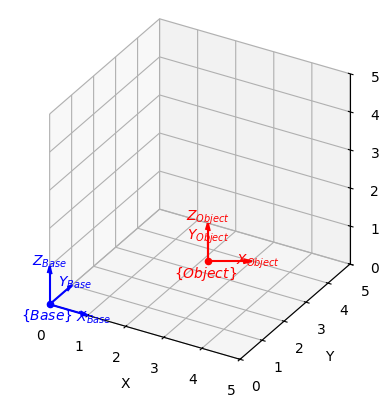

In [97]:
T_base.plot(frame='Base', color='blue', dims=[0, 5, 0, 5, 0, 5])
T_obj.plot(frame='Object', color='red')

plt.show()

## Note

Chaining Transformation:

$$T^o_B = T^E_B \times T^C_E \times T^O_C$$
